In [1]:
%matplotlib inline
# from __future__ import print_function

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import statsmodels.api as sm
# from statsmodels.formula.api im"port ols

In [2]:
# dairy = pd.read_csv('dairy_dataset.csv')
dairy = pd.read_csv('dairy_dataset.csv', parse_dates=
                    ['Date', 'Production Date', 'Expiration Date'])
# dairy['Production Date'] = dairy['Production Date'].map(pd.Timestamp.toordinal)
# dairy.head(10)
# dairy.isnull().sum()

In [3]:
# original dataset
# Filter to milk only
milk_data = dairy[dairy["Product ID"] == 1]
milk_data = milk_data.rename(columns={
    "Quantity Sold (liters/kg)": "Quantity_Sold",
    "Price per Unit (sold)": "Price_sold"
})
# Check filtered data
print(milk_data["Brand"].unique())  # Verify the included brands- 4 INCLUDED 

['Amul' 'Mother Dairy' 'Raj' 'Sudha']


In [4]:
#work on creating model- using xgboost, others failed with high pvalue and low r squared- linear regression, poly regression, with or without milk, brand, location
available_columns = milk_data.columns
features = [
    "Price per Unit", "Shelf Life (days)", "Total Value", "Price_sold", 
    "Quantity in Stock (liters/kg)", "Minimum Stock Threshold (liters/kg)",
    "Reorder Quantity (liters/kg)", "Approx. Total Revenue(INR)", 
    "Storage Condition_Tetra Pack", "Farm Size_Medium", "Farm Size_Small",
    "Sales Channel_Retail", "Sales Channel_Wholesale"
] + [col for col in milk_data.columns if col.startswith("Location_")]

features = [col for col in features if col in available_columns]
X = milk_data[features].dropna()
y = milk_data["Quantity_Sold"].loc[X.index]
#no missing values
X = X.dropna()
y = y.loc[X.index]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test_base, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
import xgboost as xgb
try:
    xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=10, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
except AttributeError:
    pass

In [7]:
y_pred_xgb = xgb_model.predict(X_test_base)
if False:
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred_xgb, alpha=0.6)
    plt.xlabel("Actual Quantity Sold")
    plt.ylabel("Predicted Quantity Sold")
    plt.title("XGBoost: Actual vs Predicted Sales")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.show()

In [8]:
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)
y_pred_xgb = xgb_model.predict(X_test_base)
# naïve forecast for MASE
naive_forecast = np.roll(y_test, shift=1)
naive_forecast[0] = y_test.mean()
# compute metrics
r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
mae_baseline = mean_absolute_error(y_test, naive_forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
mase = mae / mae_baseline
# report metrics
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")
print(f"MASE: {mase:.3f}")

R²: 0.962
MAE: 25.452
MSE: 1734.646
RMSE: 41.649
MAPE: 10.93%
MASE: 0.102


In [9]:
# forecast future sales, reggies suggestion- 3 lines
milk_data["Production Date"] = pd.to_datetime(milk_data["Production Date"])
sales_trends = (
    milk_data.groupby(milk_data["Production Date"].dt.to_period("M"))["Quantity_Sold"]
    .sum()
    .reset_index()
)
sales_trends["Production Date"] = sales_trends["Production Date"].dt.to_timestamp()
sales_trends["Date_Ordinal"] = sales_trends["Production Date"].map(pd.Timestamp.toordinal)

train_size = int(len(sales_trends) * 0.8)
train_data = sales_trends.iloc[:train_size]
test_data = sales_trends.iloc[train_size:].copy()

# ts model
X_ts = train_data[["Date_Ordinal"]]
y_ts = train_data["Quantity_Sold"]
xgb_ts_model = xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.1, random_state=42)
xgb_ts_model.fit(X_ts, y_ts)

# model forecast
X_test_timeseries = test_data[["Date_Ordinal"]]
test_data["XGBoost_Forecast"] = xgb_ts_model.predict(X_test_timeseries)

# naive forecast
test_data["Naïve_Forecast"] = train_data["Quantity_Sold"].iloc[-1]

In [10]:
import xgboost as xgb

milk_data.sort_values(by="Production Date", inplace=True)
train_size = int(len(milk_data) * 0.8)
train_data = milk_data.iloc[:train_size]
test_data = milk_data.iloc[train_size:].copy()

# ts model
X_ts = milk_data[features]
y_ts = milk_data["Quantity_Sold"]
try:
    xgb_ts_model = xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.1, random_state=42)
    xgb_ts_model.fit(X_ts, y_ts)
except AttributeError:
    pass

# model forecast
X_test_timeseries = test_data[features]
test_data["XGBoost_Forecast"] = xgb_ts_model.predict(X_test_timeseries)

# naive forecast
test_data["Naïve_Forecast"] = train_data["Quantity_Sold"].iloc[-1]

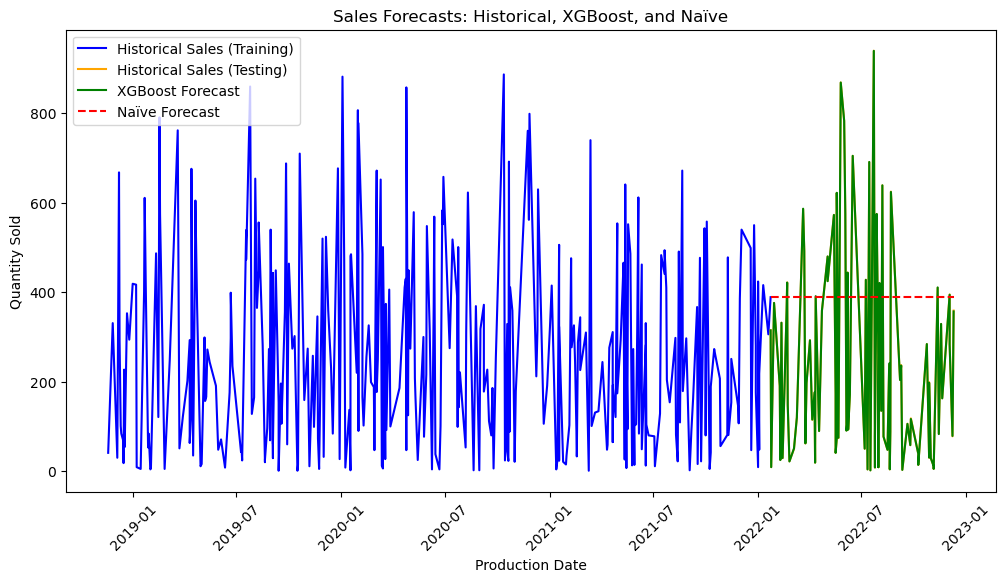

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(train_data["Production Date"], train_data["Quantity_Sold"], label="Historical Sales (Training)", color="blue")
plt.plot(test_data["Production Date"], test_data["Quantity_Sold"], label="Historical Sales (Testing)", color="orange")
plt.plot(test_data["Production Date"], test_data["XGBoost_Forecast"], label="XGBoost Forecast", color="green")
plt.plot(test_data["Production Date"], test_data["Naïve_Forecast"], label="Naïve Forecast", color="red", linestyle="--")
plt.xlabel("Production Date")
plt.ylabel("Quantity Sold")
plt.title("Sales Forecasts: Historical, XGBoost, and Naïve")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [12]:
train_data_ = train_data.groupby(train_data["Production Date"].dt.to_period("M"))\
    ["Quantity_Sold"].sum().reset_index()
train_data_["Production Date"] = train_data_["Production Date"].dt.to_timestamp()
test_data_ = test_data.groupby(test_data["Production Date"].dt.to_period("M"))\
    [["Quantity_Sold", "XGBoost_Forecast", "Naïve_Forecast"]].sum().reset_index()
test_data_["Production Date"] = test_data_["Production Date"].dt.to_timestamp()

if False:
    plt.figure(figsize=(12, 6))
    plt.plot(train_data_["Production Date"], train_data_["Quantity_Sold"], label="Historical Sales (Training)", color="blue")
    plt.plot(test_data_["Production Date"], test_data_["Quantity_Sold"], label="Historical Sales (Testing)", color="orange")
    plt.plot(test_data_["Production Date"], test_data_["XGBoost_Forecast"], label="XGBoost Forecast", color="green")
    plt.plot(test_data_["Production Date"], test_data_["Naïve_Forecast"], label="Naïve Forecast", color="red", linestyle="--")
    plt.xlabel("Production Date")
    plt.ylabel("Quantity Sold")
    plt.title("Sales Forecasts: Historical, XGBoost, and Naïve")
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

In [13]:
future_dates = pd.date_range(start="2025-05-01", periods=6, freq="ME")
brands = list(milk_data["Brand"].unique())
np.random.seed(42)

In [14]:
#ok, its ok model, lets predict the future
# add brand info
future_data = pd.DataFrame({
    "Production Date": np.tile(future_dates, len(brands)),
    "Brand": np.repeat(brands, len(future_dates)),
    "Price per Unit": np.random.uniform(50, 100, len(future_dates) * len(brands)),
    "Shelf Life (days)": np.random.choice([7, 10, 14], len(future_dates) * len(brands)),
    "Total Value": np.random.randint(5000, 10000, len(future_dates) * len(brands)),
    "Price_sold": np.random.uniform(55, 95, len(future_dates) * len(brands)),
    "Quantity in Stock (liters/kg)": np.random.randint(80, 150, len(future_dates) * len(brands)),
    "Minimum Stock Threshold (liters/kg)": np.random.randint(40, 80, len(future_dates) * len(brands)),
    "Reorder Quantity (liters/kg)": np.random.randint(30, 60, len(future_dates) * len(brands)),
    "Approx. Total Revenue(INR)": np.random.randint(5000, 10000, len(future_dates) * len(brands)),
    "Storage Condition_Tetra Pack": np.random.choice([0, 1], len(future_dates) * len(brands)),
    "Farm Size_Medium": np.random.choice([0, 1], len(future_dates) * len(brands)),
    "Farm Size_Small": np.random.choice([0, 1], len(future_dates) * len(brands)),
    "Sales Channel_Retail": np.random.choice([0, 1], len(future_dates) * len(brands)),
    "Sales Channel_Wholesale": np.random.choice([0, 1], len(future_dates) * len(brands)),
})

for col in X_train.columns:
    if col not in future_data.columns:
        future_data[col] = np.nan
        
future_data["Predicted_Quantity_Sold"] = xgb_model.predict(future_data[X_train.columns])

if False:
    plt.figure(figsize=(12, 6))
    for brand in future_data["Brand"].unique():
        brand_data = future_data[future_data["Brand"] == brand]
        plt.plot(brand_data["Production Date"], brand_data["Predicted_Quantity_Sold"],
                marker="o", label=brand)
    plt.xlabel("Production Date (Monthly)")
    plt.ylabel("Predicted Quantity Sold")
    plt.title("Future Quantity Sold Predictions by Brand")
    plt.xticks(rotation=45)
    plt.legend(title="Milk Brand")
    plt.tight_layout()
    plt.show()

In [15]:
#ehhh ok , but lets see price elasticity features 

import numpy as np
import pandas as pd
brand_groups = milk_data.groupby("Brand")

milk_brand_elasticities = {}

for brand, data in brand_groups:
    data.sort_values(by="Production Date", inplace=True)
    past_prices = data["Price_sold"].values
    past_quantities = data["Quantity_Sold"].values
    
    price_changes = np.diff(past_prices) / past_prices[:-1]
    quantity_changes = np.diff(past_quantities) / past_quantities[:-1]

    elasticity = quantity_changes / price_changes
    avg_elasticity = np.mean(elasticity)

    optimal_price = np.mean(past_prices) * (1 + (1 / avg_elasticity))

    milk_brand_elasticities[brand] = {"Avg Elasticity": avg_elasticity, "Optimal Price": optimal_price}
    
milk_brand_elasticity_df = pd.DataFrame.from_dict(milk_brand_elasticities, orient="index")
milk_brand_elasticity_df = milk_brand_elasticity_df.sort_values(by="Optimal Price", ascending=True)

# Amul inelastic so just a placeholder max price instead
max_historical_price = milk_data[milk_data["Brand"] == "Amul"]["Price_sold"].max()

adjusted_optimal_price = min(
    max_historical_price, 
    np.mean(milk_data[milk_data["Brand"] == "Amul"]["Price_sold"]) * (1 + (1 / milk_brand_elasticity_df.loc["Amul", "Avg Elasticity"]))
)

milk_brand_elasticity_df.loc["Amul", "Optimal Price"] = adjusted_optimal_price

print(milk_brand_elasticity_df)

              Avg Elasticity  Optimal Price
Amul              -34.559246      54.708971
Raj              -108.221955      55.990024
Sudha               8.058839      58.544380
Mother Dairy        0.319397     227.463376


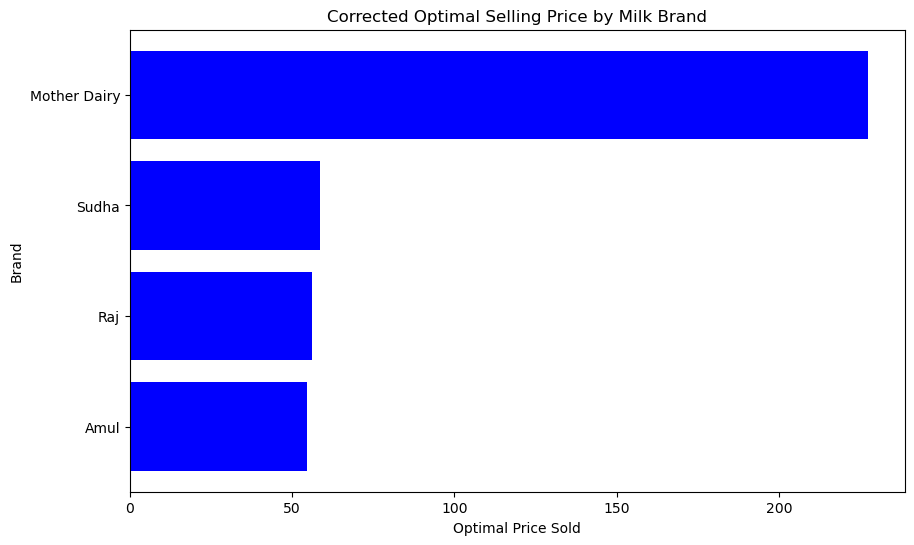

In [16]:
plt.figure(figsize=(10,6))
plt.barh(milk_brand_elasticity_df.index, milk_brand_elasticity_df["Optimal Price"], color="blue")
plt.xlabel("Optimal Price Sold")
plt.ylabel("Brand")
plt.title("Corrected Optimal Selling Price by Milk Brand")
plt.show()